## Cài đặt

In [1]:
!pip install langchain-qdrant
!pip install accelerate bitsandbytes
!pip install bert_score
!pip install xformers==0.0.28.post3 --index-url https://download.pytorch.org/whl/cu121
!pip install optimum qdrant-client wikipedia FastAPI uvicorn pyngrok
!pip install --upgrade pydantic
!pip install vllm
!pip install ragas
!pip install -U \
      python-dotenv \
      langchain \
      langchain_openai \
      langchain_community \
      langchain-huggingface \
      langchain-google-genai \
      streamlit \
      faiss-cpu \
      sentence-transformers \
      pypdf \
      docx2txt\
      vllm\
      triton
!pip install autoawq
!pip install accelerate transformers

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached triton-3.2.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.4 kB)
  Using cached autoawq-0.2.8.tar.gz (71 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for autoawq: filename=autoawq-0.2.8-py3-none-any.whl size=108744 sha256=0e8876521358ce9b8de0e38ed53f6c67ec74f25362d58e84b14f081a328fa609
  Stored in directory: /root/.cache/pip/wheels/fd/03/fe/99c1c678bfe8aca712186466969ed866f52feda95ae1dcd1b1
Successfully built autoawq


## Khởi tạo biến môi trường

In [ ]:
#Khai báo khóa API key
from google.colab import userdata
import os
os.environ["GOOGLE_API_KEY"]  = userdata.get("GOOGLE_API_KEY")

## Tải data test

In [3]:
import pandas as pd

file_path = '/content/QA_data.xlsx'
df = pd.read_excel(file_path)

In [4]:
df.head()

,question,expected_output,ground_truth
0,Tổng số tín chỉ bắt buộc của ngành Hệ thống th...,Tổng số tín chỉ bắt buộc của ngành Hệ thống th...,HTTT.txt
1,Tên văn bằng ngành Khoa học máy tính sau khi t...,Tên văn bằng ngành Khoa học máy tính sau khi t...,KHMT.txt
2,Sinh viên phải làm gì để đăng ký học phần đầu ...,"Đầu mỗi học kỳ, sinh viên phải theo dõi thông ...",QuyChe.txt
3,Sinh viên phải học môn nào bắt buộc trong chuy...,Sinh viên chuyên ngành Khoa học máy tính phải ...,KHMT.txt
4,Sinh viên phải hoàn thành bao nhiêu tín chỉ th...,Sinh viên phải hoàn thành 82 tín chỉ thuộc Kiế...,CNTT.txt


## RAG gemini

In [ ]:
# Cài đặt thông tin truy cập vector database
QDRANT_API_KEY = "-vSIHMfsf1vNQ3zo4o-8SZSk5SKxg3FOGbn1A80F7YZ0bvNmUZlWLw"
QDRANT_URL = "https://23fe2c9b-57b2-4d7d-bb77-7b72e5eeba03.eu-central-1-0.aws.cloud.qdrant.io"
EMBEDDINGS_MODEL_NAME="intfloat/multilingual-e5-base"
HUGGINGFACE_API_KEY= userdata.get("HUGGINGFACE_API_KEY")
QDRANT_COLLECTION_NAME = "ITUS_e5_600"
GENERATE_MODEL_NAME="AITeamVN/Vi-Qwen2-3B-RAG"

In [6]:
from langchain.schema.document import Document
from langchain.schema.retriever import BaseRetriever
from langchain.retrievers import WikipediaRetriever
from langchain_qdrant import QdrantVectorStore
from langchain.llms import HuggingFacePipeline
from qdrant_client import QdrantClient
from langchain.prompts import PromptTemplate
from langchain.embeddings import HuggingFaceInferenceAPIEmbeddings
from langchain.chains import RetrievalQA, MultiRetrievalQAChain
from langchain.llms import VLLM
from langchain.llms import HuggingFaceHub
from typing import List
import asyncio
from pydantic import BaseModel, Field
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from asyncio import to_thread
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chains import ConversationalRetrievalChain


class LLMServe:
    def __init__(self, model_name=GENERATE_MODEL_NAME) -> None:
        self.embeddings = self.load_embeddings()
        self.current_source = "qdrant"
        self.retriever = self.load_retriever(retriever_name=self.current_source, embeddings=self.embeddings)
        self.pipe = self.load_model_pipeline(model_name=model_name, max_new_tokens=512)
        self.prompt = self.load_prompt_template()
        self.rag_pipeline = self.load_rag_pipeline(
            llm=self.pipe,
            retriever=self.retriever,
            prompt=self.prompt
        )

    def load_embeddings(self):
        embeddings = HuggingFaceInferenceAPIEmbeddings(
            model_name=EMBEDDINGS_MODEL_NAME,
            api_key=HUGGINGFACE_API_KEY,
        )
        return embeddings

    def load_retriever(self, retriever_name, embeddings):
        """
        Load and create appropriate retriever based on retriever_name
        """
        base_retriever = None
        if retriever_name == "wiki":
            base_retriever = WikipediaRetriever(
                lang="vi",
                doc_content_chars_max=800,
                top_k_results=10
            )
        elif retriever_name == "qdrant":
            client = QdrantClient(
                url=QDRANT_URL,
                api_key=QDRANT_API_KEY,
                prefer_grpc=False
            )

            db = QdrantVectorStore(
                client=client,
                embedding=embeddings,
                collection_name=QDRANT_COLLECTION_NAME
            )
            base_retriever = db.as_retriever(search_kwargs={"k": 10})

        return base_retriever

    def load_model_pipeline(self, model_name="gemini", max_new_tokens=512):
        """
        Load and create appropriate model pipeline based on model_name
        """
        if model_name == "gemini":
            llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash")
        else:
            llm = VLLM(
                model=model_name,
                trust_remote_code=True,
                max_new_tokens=max_new_tokens,
                top_k=10,
                top_p=0.95,
                temperature=0.4,
                dtype="half",
            )
        return llm

    def load_prompt_template(self):
        query_template = """
                    <|system|>
                    '''Thực hiện trả lời câu hỏi từ thông tin có trong ngữ cảnh được cho. Chú ý các yêu cầu sau:
                    - Câu trả lời phải chính xác, đầy đủ và có liên quan đến câu hỏi.
                    - Nếu có nhiều ngữ cảnh chứa thông tin liên quan thì kết hợp các ngữ cảnh để tổng hợp.
                    - Chỉ sử dụng các thông tin có trong ngữ cảnh được cung cấp.
                    - Nếu ngữ cảnh không chứa thông tin về câu trả lời thì từ chối trả lời và không suy luận gì thêm và cung cấp thông tin liên lạc của khoa như sau để người dùng liên lạc:
                    "Vui lòng liên lạc Khoa Công Nghệ Thông Tin, trường Đại học Khoa Học Tự Nhiên - Đại học Quốc Gia TP.Hồ Chí Minh để giải đáp:
                    Địa chỉ: Phòng I.54, toà nhà I, 227 Nguyễn Văn Cừ, Q.5, TP.HCM
                    Điện thoại: (028) 62884499
                    Email: info@fit.hcmus.edu.vn"
                    </s>
                    <|user|>
                    Hãy trả lời câu hỏi sau dựa trên ngữ cảnh sau:

                    {context}
                    ---

                    Câu hỏi: {question}
                    </s>
                    <|assistant|>
                    """
        prompt = PromptTemplate(template=query_template, input_variables=["context", "question"])
        return prompt

    def load_rag_pipeline(self, llm, retriever, prompt):
        rag_pipeline = RetrievalQA.from_chain_type(
            llm=llm,
            chain_type='stuff',
            retriever=retriever,
            chain_type_kwargs={
                "prompt": prompt
            },
            return_source_documents=True,
        )
        return rag_pipeline

    def rag(self, source):
        if source == self.current_source:
            return self.rag_pipeline
        else:
            self.retriever = self.load_retriever(retriever_name=source, embeddings=self.embeddings)
            self.rag_pipeline = self.load_rag_pipeline(
                llm=self.pipe,
                retriever=self.retriever,
                prompt=self.prompt
            )
            self.current_source = source
            return self.rag_pipeline

In [7]:
# model_name = GENERATE_MODEL_NAME
app = LLMServe(model_name="gemini")

In [8]:
qa_chain = app.rag(source="qdrant")

## Test

In [9]:
eval_questions = df["question"].values

eval_answers = df["expected_output"].values

examples = [
    {"query": q, "answer": [eval_answers[i]]}
    for i, q in enumerate(eval_questions)
]

In [10]:
qa_chain("Môn học Pháp luật đại cương cung cấp kiến thức gì cho sinh viên?")

<ipython-input-10-ee5d745548c6>:1: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  qa_chain("Môn học Pháp luật đại cương cung cấp kiến thức gì cho sinh viên?")


{'query': 'Môn học Pháp luật đại cương cung cấp kiến thức gì cho sinh viên?',
 'result': 'Môn học Pháp luật đại cương cung cấp cho sinh viên những kiến thức cơ bản về nhà nước và pháp luật, bộ máy nhà nước và hệ thống pháp luật Việt Nam hiện tại.  Nó cũng trang bị kiến thức cơ bản về pháp luật phòng, chống tham nhũng, nhằm nâng cao ý thức sống, học tập và làm việc theo Hiến pháp và pháp luật.  Ngoài ra, môn học còn hướng đến mục tiêu phát triển nhận thức của sinh viên về các vấn đề này.  Nội dung môn học bao gồm các chủ đề như quy phạm pháp luật, quan hệ pháp luật, hệ thống văn bản quy phạm pháp luật ở Việt Nam, thực hiện pháp luật, vi phạm pháp luật, ý thức pháp luật,  các ngành luật trong hệ thống pháp luật Việt Nam (Luật Hiến pháp, Luật Dân sự, Luật Tố tụng Dân sự, Luật Hình sự, Luật Tố tụng Hình sự), và các vấn đề chung về phòng, chống tham nhũng (khái niệm và phân loại hành vi tham nhũng, xử lý hành vi tham nhũng, trách nhiệm của cá nhân, cơ quan, tổ chức trong công tác phòng, chố

#Đánh giá

In [11]:
import time
dataset = []

predictions=[]
data_size = len(examples)
for i in range(data_size):
  print("Processing...("+str(i)+"/"+str(data_size)+")")
  while True:
    try:
      predictions += [qa_chain(examples[i])]
      break  # Exit the loop if successful
    except Exception as e:
      print(f"Error: {e}")  # Print the error message
      time.sleep(5)

  dataset.append(
        {
            "user_input":examples[i]['query'],
            "retrieved_contexts": predictions[i]["source_documents"],
            "response":predictions[i]["result"],
            "reference":str(examples[i]['answer'][0])
        }
  )

Processing...(0/144)
Processing...(1/144)
Processing...(2/144)
Processing...(3/144)
Processing...(4/144)
Processing...(5/144)
Processing...(6/144)
Processing...(7/144)
Processing...(8/144)
Processing...(9/144)
Processing...(10/144)
Processing...(11/144)
Processing...(12/144)
Processing...(13/144)
Processing...(14/144)
Processing...(15/144)


Error: 429 Resource has been exhausted (e.g. check quota).


Error: 429 Resource has been exhausted (e.g. check quota).
Processing...(16/144)
Processing...(17/144)
Processing...(18/144)
Processing...(19/144)
Processing...(20/144)
Processing...(21/144)
Processing...(22/144)
Processing...(23/144)
Processing...(24/144)
Processing...(25/144)
Processing...(26/144)
Processing...(27/144)
Processing...(28/144)
Processing...(29/144)
Processing...(30/144)
Processing...(31/144)


Error: 429 Resource has been exhausted (e.g. check quota).


Error: 429 Resource has been exhausted (e.g. check quota).


...

Error: 429 Resource has been exhausted (e.g. check quota).


Error: 429 Resource has been exhausted (e.g. check quota).


Error: 429 Resource has been exhausted (e.g. check quota).
Processing...(92/144)
Processing...(93/144)
Processing...(94/144)
Processing...(95/144)
Processing...(96/144)
Processing...(97/144)
Processing...(98/144)
Processing...(99/144)
Processing...(100/144)
Processing...(101/144)
Processing...(102/144)
Processing...(103/144)
Processing...(104/144)
Processing...(105/144)
Processing...(106/144)
Processing...(107/144)
Processing...(108/144)
Processing...(109/144)
Processing...(110/144)
Processing...(111/144)
Processing...(112/144)
Processing...(113/144)
Processing...(114/144)
Processing...(115/144)
Processing...(116/144)
Processing...(117/144)
Processing...(118/144)
Processing...(119/144)
Processing...(120/144)
Processing...(121/144)
Processing...(122/144)
Processing...(123/144)
Processing...(124/144)
Processing...(125/144)
Processing...(126/144)
Processing...(127/144)
Processing...(128/144)
Processing...(129/144)
Processing...(130/144)
Processing...(131/144)
Processing...(132/144)
Proces

Error: 429 Resource has been exhausted (e.g. check quota).


Error: 429 Resource has been exhausted (e.g. check quota).
Processing...(141/144)
Processing...(142/144)
Processing...(143/144)


In [12]:
import json
import pandas as pd

# Lưu lại kết quả chạy
pd.DataFrame(dataset).to_csv(f"gemini_data_result.csv")


In [13]:
from bert_score import score

# Example texts
candidates = [str(x["response"]) for x in dataset]
references = [str(x["reference"]) for x in dataset]

# Calculate BERTScore
P, R, F1 = score(candidates, references, lang='vi', verbose=True)

# Print scores
print(f"Precision: {P.mean()}")
print(f"Recall: {R.mean()}")
print(f"F1 Score: {F1.mean()}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/4 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/3 [00:00<?, ?it/s]

done in 109.37 seconds, 1.32 sentences/sec
Precision: 0.891310453414917
Recall: 0.9163451790809631
F1 Score: 0.9026225209236145


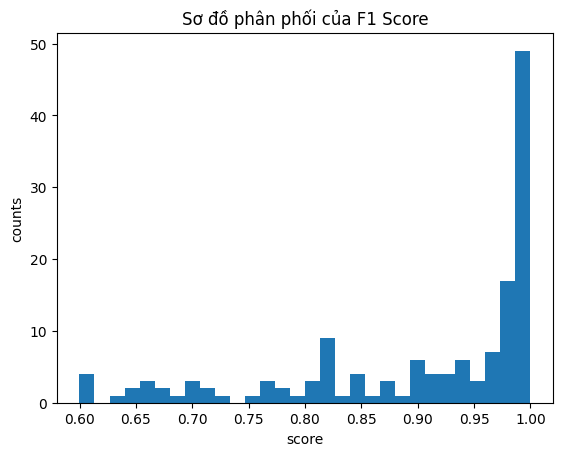

In [14]:
import matplotlib.pyplot as plt
plt.hist(F1, bins=30)
plt.xlabel("score")
plt.ylabel("counts")
plt.title("Sơ đồ phân phối của F1 Score")
plt.show()

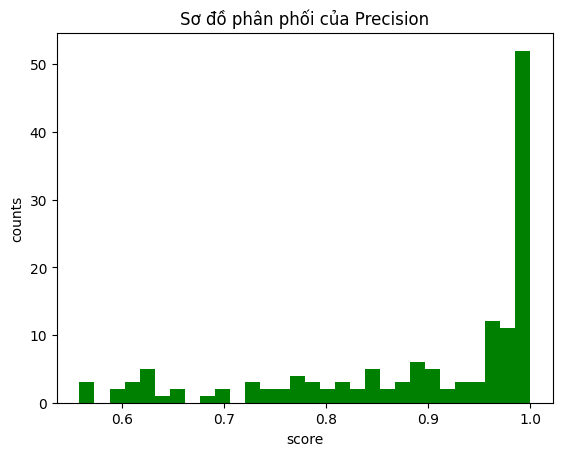

In [15]:
import matplotlib.pyplot as plt
plt.hist(P, bins=30,color="green")
plt.xlabel("score")
plt.ylabel("counts")
plt.title("Sơ đồ phân phối của Precision")
plt.show()

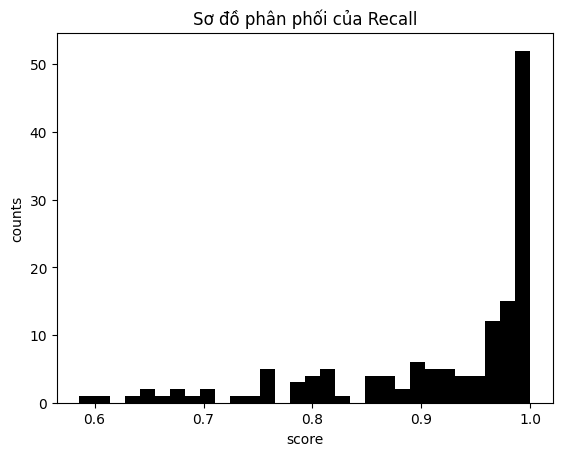

In [16]:
import matplotlib.pyplot as plt
plt.hist(R, bins=30,color="black")
plt.xlabel("score")
plt.ylabel("counts")
plt.title("Sơ đồ phân phối của Recall")
plt.show()

In [17]:
#tải dữ liệu từ gemini_data_result.csv
import pandas as pd
from langchain.schema.document import Document
df = pd.read_csv('/content/gemini_data_result.csv')
#chuyển df thành list
dataset = df.to_dict('records')
#chuyển dữ liệu chuỗi trong dataset thành eval bằng vòng for x= eval(x)
for x in dataset:
    x['retrieved_contexts'] = eval(x['retrieved_contexts'])


In [18]:
import json
import pandas as pd
for item in dataset:
    if isinstance(item['retrieved_contexts'][0], Document):
        item['retrieved_contexts'] = [dt.page_content for dt in item['retrieved_contexts']]
    else:
        item['retrieved_contexts'] = item['retrieved_contexts']
    item['reference'] = str(item['reference'])

with open(f'gemini_data_result.json', 'w', encoding='utf-8') as f:
    json.dump(dataset, f)


In [19]:
from ragas import EvaluationDataset
evaluation_dataset = EvaluationDataset.from_list(dataset)

In [20]:
from langchain_google_genai import ChatGoogleGenerativeAI
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper

evaluator_llm = LangchainLLMWrapper(ChatGoogleGenerativeAI(model="gemini-1.5-flash"))
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness

result = evaluate(dataset=evaluation_dataset,metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness()],llm=evaluator_llm)

Evaluating:   0%|          | 0/432 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[20]: ResourceExhausted(429 Resource has been exhausted (e.g. check quota).)
ERROR:ragas.executor:Exception raised in Job[13]: ResourceExhausted(429 Resource has been exhausted (e.g. check quota).)
ERROR:ragas.executor:Exception raised in Job[4]: ResourceExhausted(429 Resource has been exhausted (e.g. check quota).)
ERROR:ragas.executor:Exception raised in Job[16]: ResourceExhausted(429 Resource has been exhausted (e.g. check quota).)
ERROR:ragas.executor:Exception raised in Job[11]: ResourceExhausted(429 Resource has been exhausted (e.g. check quota).)
ERROR:ragas.executor:Exception raised in Job[1]: ResourceExhausted(429 Resource has been exhausted (e.g. check quota).)
ERROR:ragas.executor:Exception raised in Job[10]: ResourceExhausted(429 Resource has been exhausted (e.g. check quota).)
ERROR:ragas.executor:Exception raised in Job[21]: ResourceExhausted(429 Resource has been exhausted (e.g. check quota).)
ERROR:ragas.executor:Exception rai

In [21]:
result

{'context_recall': 0.9279, 'faithfulness': 0.9144, 'factual_correctness': 0.7107}

In [22]:
df = result.to_pandas()
df

,user_input,retrieved_contexts,response,reference,context_recall,faithfulness,factual_correctness
0,Tổng số tín chỉ bắt buộc của ngành Hệ thống th...,[7.2.1. Kiến thức cơ sở ngành Ngành Hệ thống T...,Tổng số tín chỉ bắt buộc của ngành Hệ thống th...,Tổng số tín chỉ bắt buộc của ngành Hệ thống th...,0.500000,NaN,0.0
1,Tên văn bằng ngành Khoa học máy tính sau khi t...,[1.3. Trình độ đào tạo: Đại học \n1.4. Tên chư...,Tên văn bằng ngành Khoa học máy tính sau khi t...,Tên văn bằng ngành Khoa học máy tính sau khi t...,0.666667,NaN,1.0
2,Sinh viên phải làm gì để đăng ký học phần đầu ...,[1.2.2.1. Đăng ký học phần: \na) Đầu mỗi học k...,"Đầu mỗi học kỳ, sinh viên phải theo dõi thông ...","Đầu mỗi học kỳ, sinh viên phải theo dõi thông ...",1.000000,1.0,NaN
3,Sinh viên phải học môn nào bắt buộc trong chuy...,[7.2.2. Kiến thức ngành/ chuyên ngành Ngành Kh...,"Dựa trên ngữ cảnh được cung cấp, sinh viên chu...",Sinh viên chuyên ngành Khoa học máy tính phải ...,1.000000,NaN,NaN
4,Sinh viên phải hoàn thành bao nhiêu tín chỉ th...,[6.2.1. Cơ sở ngành\nTổng cộng 38 tín chỉ bao ...,Sinh viên phải hoàn thành 82 tín chỉ thuộc Kiế...,Sinh viên phải hoàn thành 82 tín chỉ thuộc Kiế...,1.000000,NaN,NaN
...,...,...,...,...,...,...,...
139,Các môn học học kỳ 1 năm 3 của ngành Công nghệ...,[8.2.5. Các môn học Học kỳ 1 năm 3 Chuyên ngàn...,Các môn học học kỳ 1 năm 3 của ngành Công nghệ...,Các môn học học kỳ 1 năm 3 của ngành Công nghệ...,NaN,NaN,NaN
140,Ngành Công nghệ thông tin yêu cầu bao nhiêu tí...,[2.4. Cơ hội nghề nghiệp Ngành Công nghệ thông...,Ngành Công nghệ thông tin yêu cầu 138 tín chỉ ...,Ngành Công nghệ thông tin yêu cầu 10 tín chỉ t...,NaN,NaN,NaN
141,Các môn học của học kỳ hè năm 2 ngành Công ngh...,[8.2.4. Các môn học Học kỳ 2 năm 2 Chuyên ngàn...,Môn học của học kỳ hè năm 2 ngành Công nghệ th...,Môn học của học kỳ hè năm 2 ngành Công nghệ th...,NaN,NaN,NaN
142,Sinh viên được yêu cầu về kỹ năng ngoại ngữ nào?,[10. Triển khai hệ thống truy xuất thông tin\n...,Sinh viên cần đạt chuẩn tiếng Anh trong quá tr...,Sinh viên cần đạt được chuẩn tiếng Anh trong q...,NaN,NaN,NaN


In [23]:
#in ra các cột df có giá trị factual_correctness cao
df[df['factual_correctness'] == df['factual_correctness']]

,user_input,retrieved_contexts,response,reference,context_recall,faithfulness,factual_correctness
0,Tổng số tín chỉ bắt buộc của ngành Hệ thống th...,[7.2.1. Kiến thức cơ sở ngành Ngành Hệ thống T...,Tổng số tín chỉ bắt buộc của ngành Hệ thống th...,Tổng số tín chỉ bắt buộc của ngành Hệ thống th...,0.500000,NaN,0.00
1,Tên văn bằng ngành Khoa học máy tính sau khi t...,[1.3. Trình độ đào tạo: Đại học \n1.4. Tên chư...,Tên văn bằng ngành Khoa học máy tính sau khi t...,Tên văn bằng ngành Khoa học máy tính sau khi t...,0.666667,NaN,1.00
5,Sinh viên phải đăng ký tối thiểu bao nhiêu tín...,"[1.2.2.2. Số tín chỉ tối thiểu, tối đa trong h...",Số tín chỉ tối thiểu đăng ký trong học kỳ chín...,"Đối với chương trình Tiên tiến, Liên kết, Chất...",1.000000,NaN,1.00
10,Sinh viên cần làm gì để được hoãn thi trong tr...,[1.3.4. Điều 12. Hoãn thi \n1.3.4.1. Những tr...,Trong trường hợp đột xuất và có lý do chính đá...,Trong trường hợp đột xuất và có lý do chính đá...,1.000000,NaN,1.00
13,Sinh viên cần đáp ứng những điều kiện nào để đ...,[1.3.9.6. Căn cứ kết quả xét tốt nghiệp và đề ...,Sinh viên cần đáp ứng các điều kiện sau để đượ...,Sinh viên được xét và công nhận tốt nghiệp khi...,NaN,1.0,0.86
14,Những học phần nào được xem là bắt buộc trong ...,[1.1.3.1. Học phần \nb) Có hai loại học phần: ...,"Dựa trên ngữ cảnh được cung cấp, học phần bắt ...",Học phần bắt buộc là học phần chứa đựng những ...,1.000000,1.0,0.57
16,Ngành Công nghệ thông tin được giảng dạy bằng ...,[7.2.1. Kiến thức cơ sở ngành Ngành Công nghệ ...,Ngành Công nghệ thông tin được giảng dạy bằng ...,Ngành Công nghệ thông tin được giảng dạy bằng ...,NaN,1.0,1.00
18,Mục tiêu học phần của khóa học Thị giác robot ...,[112. CSC16104 - Thị giác robot\nTên học phần ...,Mục tiêu học phần của khóa học Thị giác robot ...,Mục tiêu học phần của khóa học Thị giác robot:...,1.000000,1.0,1.00
19,Mục tiêu học phần CSC17104 là gì?,[120. CSC17104 - Lập trình cho khoa học dữ liệ...,Ngữ cảnh không cung cấp mục tiêu học phần của ...,Mục tiêu học phần CSC17104 bao gồm: Sử dụng lệ...,NaN,NaN,0.00
20,Mục tiêu của khóa học 'Thực hành Hóa đại cương...,[8. CHE00082 - Thực hành Hóa đại cương 2\nVị t...,"Mục tiêu của khóa học ""Thực hành Hóa đại cương...","Sau khi hoàn thành thành công học phần này, si...",1.000000,1.0,0.20


In [24]:
df.to_csv("ragas_genimi_result.csv")

In [25]:
# load lại data từ ragas_genimi_result_FITHCMUSv1_1000.csv
import pandas as pd
df = pd.read_csv('/content/ragas_genimi_result.csv')


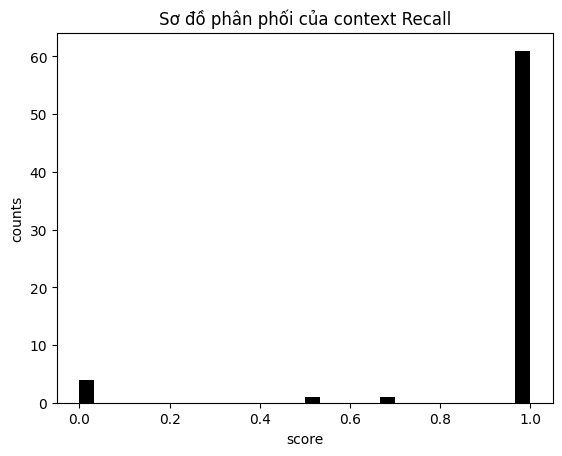

In [26]:
import matplotlib.pyplot as plt
plt.hist(df['context_recall'], bins=30,color="black")
plt.xlabel("score")
plt.ylabel("counts")
plt.title("Sơ đồ phân phối của context Recall")
plt.show()

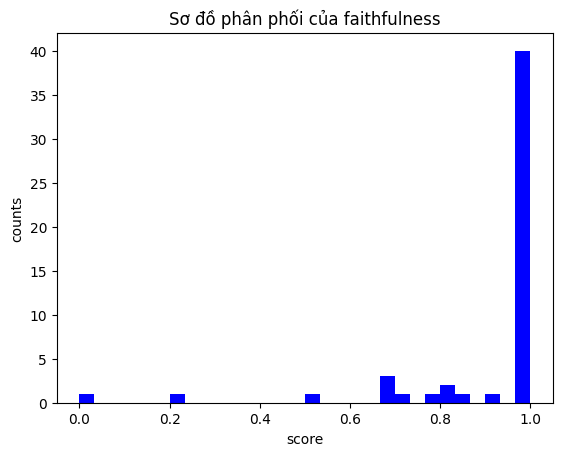

In [27]:
import matplotlib.pyplot as plt
plt.hist(df['faithfulness'], bins=30,color="blue")
plt.xlabel("score")
plt.ylabel("counts")
plt.title("Sơ đồ phân phối của faithfulness")
plt.show()

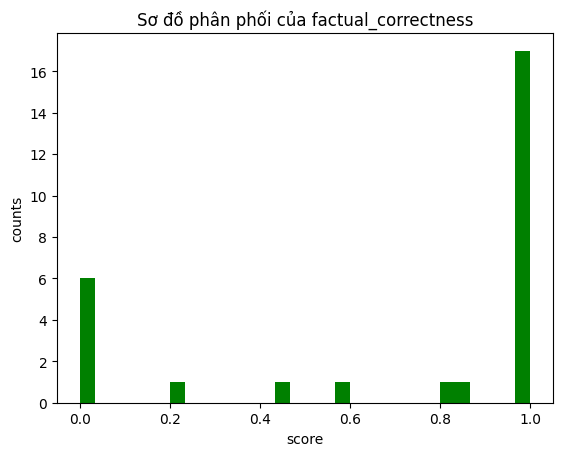

In [28]:
import matplotlib.pyplot as plt
plt.hist(df['factual_correctness'], bins=30,color="green")
plt.xlabel("score")
plt.ylabel("counts")
plt.title("Sơ đồ phân phối của factual_correctness")
plt.show()